In [6]:
import csv
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from skimage.color import rgb2gray
from skimage import exposure
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate # Used to get both train and test scores
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, make_scorer

In [ ]:
# Column indices for the 4 outputs 
X_COL, Y_COL, XW_COL, YW_COL = 1, 2, 3, 4 
RANDOM_STATE = 42 
N_JOBS = -1 
CV_FOLDS = 5 
# Define the scorer (MSE is minimized, so we use negative MSE)
NEG_MSE_SCORER = make_scorer(mean_squared_error, greater_is_better=False)

1. Load and Preprocess Data

In [ ]:
images = []
all_outputs = []
rootpath = 'Training'
prefix = rootpath + '/' 

try:
    with open(prefix + 'myData'+ '.csv', 'r') as gtFile:
        gtReader = csv.reader(gtFile, delimiter=';')
        next(gtReader) # Skip header row
        
        for row in gtReader:
            if not row or len(row) <= YW_COL:
                continue
            
            # Image Loading
            img_path = prefix + row[0]
            img = Image.open(img_path)

            # Resize to 32x32
            img = img.resize((32, 32), Image.BICUBIC) 
            img_array = np.array(img)

            # Convert to grayscale
            gray_img = rgb2gray(img_array)
            
            # Apply CLAHE (Contrast Enhancement)
            clache_img = exposure.equalize_adapthist(gray_img, clip_limit=0.03)
            
            images.append(clache_img) 
            
            # Read all 4 outputs 
            x = int(row[X_COL])
            y = int(row[Y_COL])
            xw = int(row[XW_COL])
            yw = int(row[YW_COL])
            all_outputs.append([x, y, xw, yw])

except FileNotFoundError:
    print(f"Error: Training file not found at {prefix + 'myData.csv'}")
    exit()
except Exception as e:
    print(f"Skipping row due to error: {e}")
    
Y_data = np.array(all_outputs)
raw_images = images

print(f'Total number of samples loaded: {len(Y_data)}')

X_data = []
for img in raw_images:
    X_data.append(img.flatten())
X_data = np.array(X_data)

print(f'Shape of feature matrix X: {X_data.shape}')

Total number of samples loaded: 150
Shape of feature matrix X: (150, 1024)


2. Kernel Testing

In [4]:
# cross_val_score function itself includes both the training and validation processes (testing) across multiple folds.

def evaluate_model_dual_mse(model, X, Y):
    """
    Runs K-Fold CV using cross_validate to return the average positive 
    Training MSE and Validation MSE.
    """
    # cross_validate is used with return_train_score=True to get both training and validation scores
    cv_results = cross_validate(model, X, Y, scoring=NEG_MSE_SCORER, cv=CV_FOLDS, n_jobs=N_JOBS, return_train_score=True)
    
    # Negate and average the scores to convert from negative to positive MSE
    avg_train_mse = np.mean(-cv_results['train_score'])
    avg_val_mse = np.mean(-cv_results['test_score'])
    
    # Returns both MSEs
    return avg_train_mse, avg_val_mse

In [9]:
kernel_options = ['linear', 'rbf', 'poly', 'sigmoid']
kernel_mse_results = {}

for kernel1 in kernel_options:
    print(f"\nEvaluating Kernel: {kernel1}...")
    
    # 1. Define the base single-output SVR model
    base_svr = SVR(kernel=kernel1)

    # 2. Wrap it to handle multiple outputs
    # This creates 4 separate SVR models, one for each column in Y
    multioutput_svr = MultiOutputRegressor(base_svr)

    avg_train_mse, avg_val_mse = evaluate_model_dual_mse(multioutput_svr, X_data, Y_data)
    kernel_mse_results[kernel1] = (avg_train_mse, avg_val_mse)
    print(f"  Kernel: {kernel1:<6} -> Train MSE: {avg_train_mse:.4f} | Val MSE: {avg_val_mse:.4f}")


Evaluating Kernel: linear...
  Kernel: linear -> Train MSE: 296.0165 | Val MSE: 1317.9303

Evaluating Kernel: rbf...
  Kernel: rbf    -> Train MSE: 2895.0673 | Val MSE: 3015.1851

Evaluating Kernel: poly...
  Kernel: poly   -> Train MSE: 235.3868 | Val MSE: 1361.6131

Evaluating Kernel: sigmoid...
  Kernel: sigmoid -> Train MSE: 3004.9456 | Val MSE: 3071.1289


Plotting Results

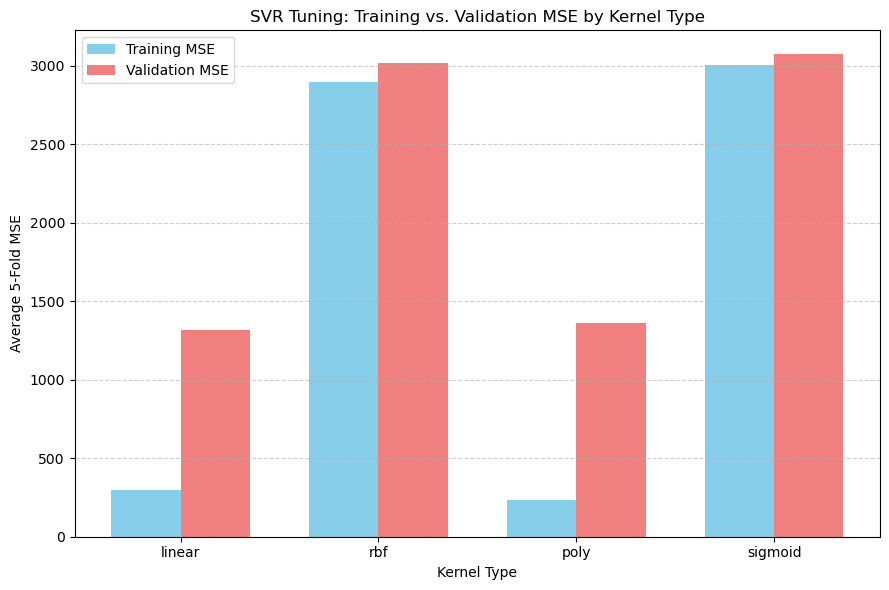

In [ ]:
# Extract data for plotting
kernels = list(kernel_mse_results.keys())

# Extracting the Training MSE (index 0) and Validation MSE (index 1) for each kernel
train_mse_values = [v[0] for v in kernel_mse_results.values()]
val_mse_values = [v[1] for v in kernel_mse_results.values()]

x = np.arange(len(kernels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(9, 6))

# Bar for Training MSE (blue)
rects1 = ax.bar(x - width/2, train_mse_values, width, label='Training MSE', color='skyblue')
# Bar for Validation MSE (red)
rects2 = ax.bar(x + width/2, val_mse_values, width, label='Validation MSE', color='lightcoral')

# Add some text for labels, title, and custom x-axis tick labels, etc.
ax.set_ylabel(f'Average {CV_FOLDS}-Fold MSE')
ax.set_xlabel('Kernel Type')
ax.set_title(f'SVR Tuning: Training vs. Validation MSE by Kernel Type')
ax.set_xticks(x)
ax.set_xticklabels(kernels)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Function to attach a text label above each bar showing its height
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rects.width / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()

3. c parameter Testing

Define plot_tuning_results_dual_mse() which plots the average Training and Validation MSE vs. the tested parameter values

In [ ]:
def plot_tuning_results_dual_mse(results, param_name, log_scale=False):

    params = list(results.keys())
    train_mse_values = [v[0] for v in results.values()]
    val_mse_values = [v[1] for v in results.values()]
    
    plt.figure(figsize=(10, 6))
    
    plt.plot(params, train_mse_values, marker='o', linestyle='-', color='b', label='Training MSE')
    plt.plot(params, val_mse_values, marker='s', linestyle='-', color='r', label='Validation MSE')
    
    best_param = min(results, key=lambda k: results[k][1]) 
    best_val_mse = results[best_param][1]
    
    plt.plot(best_param, best_val_mse, marker='*', markersize=15, color='g', label=f'Optimal Val: {best_param}', linestyle='')
    
    plt.xlabel(f'{param_name} Value')
    plt.ylabel(f'Average {CV_FOLDS}-Fold MSE')
    plt.title(f'SVR Tuning: Training vs. Validation MSE vs. {param_name}')
    plt.legend()
    
    if log_scale:
        plt.xscale('log')
    
    plt.grid(True, which='both', linestyle='--', alpha=0.6)
    plt.show()

Plotting Results


[STEP 2] Tuning C Parameter (Using Logarithmic Range)...
  C: 0.0010 -> Train MSE: 2994.3266 | Val MSE: 3063.7189
  C: 0.0046 -> Train MSE: 2955.9101 | Val MSE: 3037.1473
  C: 0.0215 -> Train MSE: 2784.0147 | Val MSE: 2918.0889
  C: 0.1000 -> Train MSE: 2112.1108 | Val MSE: 2470.2805
  C: 0.4642 -> Train MSE: 782.8654 | Val MSE: 1583.1329
  C: 2.1544 -> Train MSE: 56.7108 | Val MSE: 1243.0658
  C: 10.0000 -> Train MSE: 0.0100 | Val MSE: 1282.2330
  C: 46.4159 -> Train MSE: 0.0100 | Val MSE: 1282.2330
  C: 215.4435 -> Train MSE: 0.0100 | Val MSE: 1282.2330
  C: 1000.0000 -> Train MSE: 0.0100 | Val MSE: 1282.2330


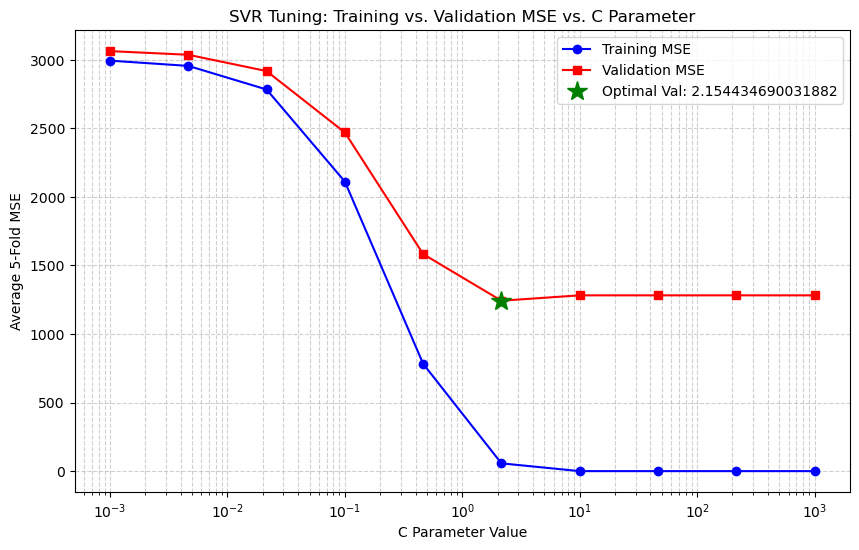


-> Optimal C selected: **2.1544**
  C: 0.0010 -> Train MSE: 3004.8747 | Val MSE: 3071.1066
  C: 0.0046 -> Train MSE: 3004.4674 | Val MSE: 3070.8973
  C: 0.0215 -> Train MSE: 3002.5780 | Val MSE: 3069.9262
  C: 0.1000 -> Train MSE: 2993.8195 | Val MSE: 3065.4230
  C: 0.4642 -> Train MSE: 2953.5700 | Val MSE: 3044.8834
  C: 2.1544 -> Train MSE: 2771.3642 | Val MSE: 2951.9949
  C: 10.0000 -> Train MSE: 2047.8665 | Val MSE: 2589.7842
  C: 46.4159 -> Train MSE: 502.3068 | Val MSE: 1733.1216
  C: 215.4435 -> Train MSE: 0.9606 | Val MSE: 1392.8933
  C: 1000.0000 -> Train MSE: 0.0100 | Val MSE: 1391.3236


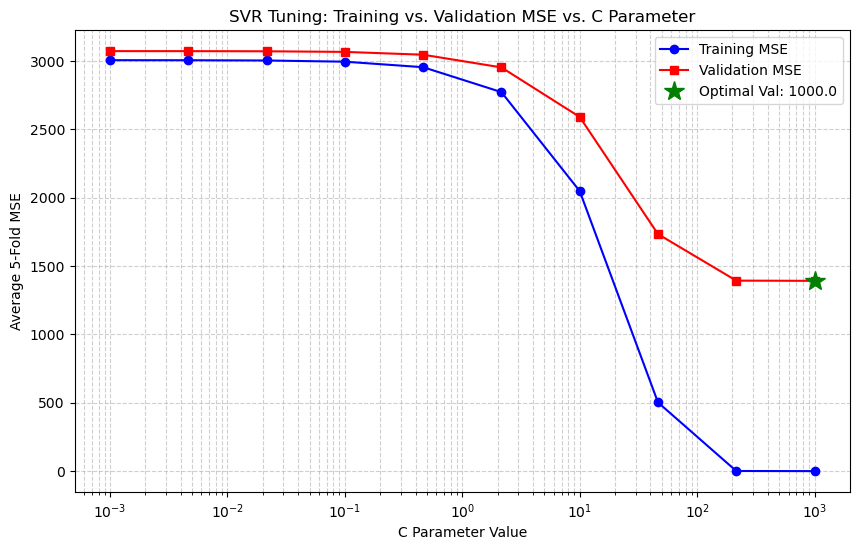


-> Optimal C selected: **1000.0000**
  C: 0.0010 -> Train MSE: 2993.3242 | Val MSE: 3063.4494
  C: 0.0046 -> Train MSE: 2951.4723 | Val MSE: 3036.0301
  C: 0.0215 -> Train MSE: 2764.8856 | Val MSE: 2911.3282
  C: 0.1000 -> Train MSE: 2049.8619 | Val MSE: 2455.2096
  C: 0.4642 -> Train MSE: 698.0178 | Val MSE: 1596.2408
  C: 2.1544 -> Train MSE: 35.8676 | Val MSE: 1274.3967
  C: 10.0000 -> Train MSE: 0.0100 | Val MSE: 1277.0080
  C: 46.4159 -> Train MSE: 0.0100 | Val MSE: 1277.0080
  C: 215.4435 -> Train MSE: 0.0100 | Val MSE: 1277.0080
  C: 1000.0000 -> Train MSE: 0.0100 | Val MSE: 1277.0080


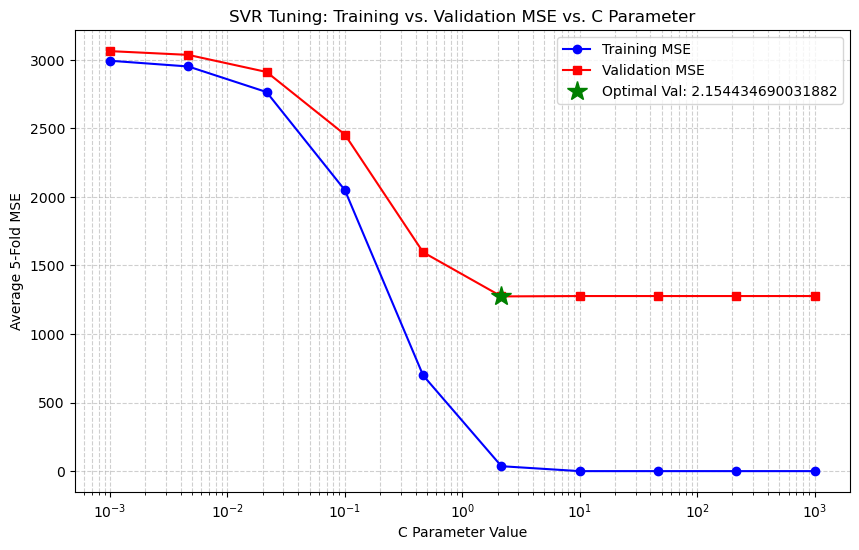


-> Optimal C selected: **2.1544**
  C: 0.0010 -> Train MSE: 3004.9865 | Val MSE: 3071.1641
  C: 0.0046 -> Train MSE: 3004.9863 | Val MSE: 3071.1640
  C: 0.0215 -> Train MSE: 3004.9856 | Val MSE: 3071.1634
  C: 0.1000 -> Train MSE: 3004.9824 | Val MSE: 3071.1607
  C: 0.4642 -> Train MSE: 3004.9675 | Val MSE: 3071.1479
  C: 2.1544 -> Train MSE: 3004.8985 | Val MSE: 3071.0882
  C: 10.0000 -> Train MSE: 3004.5780 | Val MSE: 3070.8115
  C: 46.4159 -> Train MSE: 3003.0923 | Val MSE: 3069.5284
  C: 215.4435 -> Train MSE: 2996.2231 | Val MSE: 3063.6519
  C: 1000.0000 -> Train MSE: 2964.8534 | Val MSE: 3038.1557


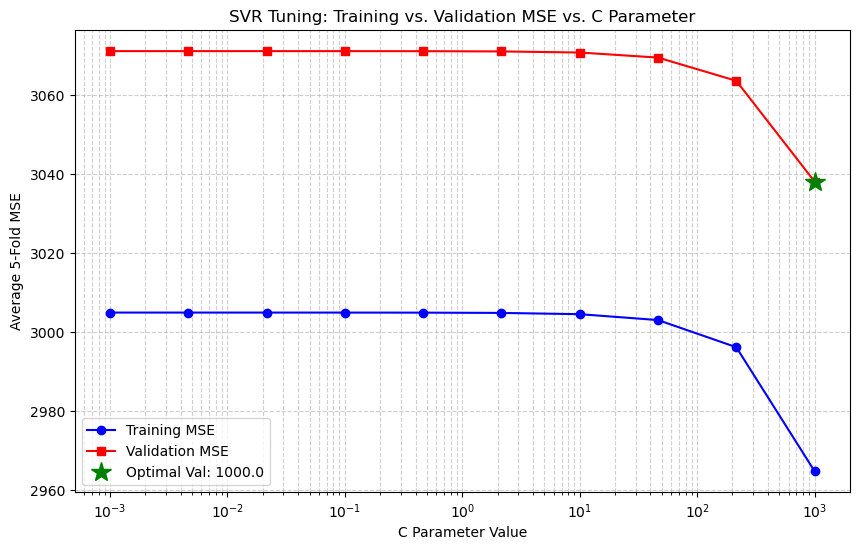


-> Optimal C selected: **1000.0000**


In [14]:
print("\n[STEP 2] Tuning C Parameter (Using Logarithmic Range)...")
# Typical broad search range from 10^-3 to 10^3
c_options = np.logspace(-3, 3, 10) 
c_mse_results = {}

for kernel1 in kernel_options:
    for c_val in c_options:
        
        # 1. Define the base single-output SVR model
        base_svr = SVR(kernel=kernel1, C=c_val)

        # 2. Wrap it to handle multiple outputs
        # This creates 4 separate SVR models, one for each column in Y
        multioutput_svr = MultiOutputRegressor(base_svr)

        
        avg_train_mse, avg_val_mse = evaluate_model_dual_mse(multioutput_svr, X_data, Y_data)
        c_mse_results[c_val] = (avg_train_mse, avg_val_mse)
        print(f"  C: {c_val:.4f} -> Train MSE: {avg_train_mse:.4f} | Val MSE: {avg_val_mse:.4f}")

    plot_tuning_results_dual_mse(c_mse_results, 'C Parameter', log_scale=True)
    OPTIMAL_C = min(c_mse_results, key=lambda k: c_mse_results[k][1])
    print(f"\n-> Optimal C selected: **{OPTIMAL_C:.4f}**")